In [91]:
import xarray as xr

# based on equation indicated in https://croco-ocean.gitlabpages.inria.fr/croco_doc/model/model.grid.html

In [84]:
grd = xr.open_dataset("/Users/todaka/data/RIOMAR/croco_grd.nc")
grd
# <xarray.DataArray 'h' (y_rho: 60, x_rho: 75)>  ← should match ds shape

<xarray.Dataset> Size: 141MB
Dimensions:    (one: 1, eta_rho: 838, xi_rho: 727, bath: 1, eta_u: 838,
                xi_u: 726, eta_v: 837, xi_v: 727, eta_psi: 837, xi_psi: 726)
Dimensions without coordinates: one, eta_rho, xi_rho, bath, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi
Data variables: (12/34)
    xl         (one) float64 8B ...
    el         (one) float64 8B ...
    depthmin   (one) float64 8B ...
    depthmax   (one) float64 8B ...
    spherical  (one) |S1 1B ...
    angle      (eta_rho, xi_rho) float64 5MB ...
    ...         ...
    lat_v      (eta_v, xi_v) float64 5MB ...
    lat_psi    (eta_psi, xi_psi) float64 5MB ...
    mask_rho   (eta_rho, xi_rho) float64 5MB ...
    mask_u     (eta_u, xi_u) float64 5MB ...
    mask_v     (eta_v, xi_v) float64 5MB ...
    mask_psi   (eta_psi, xi_psi) float64 5MB ...
Attributes:
    title:    BOB1000 Model
    date:     09-Mar-2023
    type:     CROCO grid file

In [ ]:
import numpy as np
import xarray as xr

# https://data-fair2adapt.ifremer.fr/riomar/GAMAR/small_time.nc
ds = xr.open_dataset("/Users/todaka/data/RIOMAR/small_time.nc")

# ── Parameters from attributes ────────────────────────────────────────────────
hc = float(ds.attrs["hc"])  # 15.0  m
theta_s = float(ds.attrs["theta_s"])  # 6.0
theta_b = float(ds.attrs["theta_b"])  # 4.0

# ── σ levels (s_rho coordinate, values in [-1, 0]) ───────────────────────────
sigma = ds["s_rho"]  # dim: (s_rho,)

# ── Cs(σ) — NEW_S_COORD stretching function ───────────────────────────────────
# Try reading from file first (the attrs say it is stored as variable Cs_r)
if "Cs_r" in ds:
    Cs = ds["Cs_r"]  # dim: (s_rho,)
else:
    # Compute analytically (NEW_S_COORD / Vtransform=2)
    csf = (
        (1.0 - np.cosh(theta_s * sigma)) / (np.cosh(theta_s) - 1.0)
        if theta_s > 0
        else -(sigma**2)
    )
    Cs = (
        (np.exp(theta_b * csf) - 1.0) / (1.0 - np.exp(-theta_b)) if theta_b > 0 else csf
    )
Cs

grd = xr.open_dataset("/Users/todaka/data/RIOMAR/croco_grd.nc")
h = (
    grd["h"]
    .assign_coords(
        nav_lat=(["eta_rho", "xi_rho"], grd["lat_rho"].values),
        nav_lon=(["eta_rho", "xi_rho"], grd["lon_rho"].values),
    )
    .rename({"eta_rho": "y_rho", "xi_rho": "x_rho"})
)
h

In [86]:
# ── z0(σ, y, x)  —  static part (no time dependence) ─────────────────────────
# Broadcasting: sigma/Cs are (s_rho,), h is (y_rho, x_rho)
# → z0 becomes (s_rho, y_rho, x_rho)
z0 = (hc * sigma + h * Cs) / (hc + h)

# ── z(t, σ, y, x)  —  full time-dependent depth ──────────────────────────────
# zeta is (time_counter, y_rho, x_rho)
# z0   is (s_rho, y_rho, x_rho)
# → z  becomes (time_counter, s_rho, y_rho, x_rho)
zeta = ds["zeta"]
z = zeta + (zeta + h) * z0

z = z.rename("z")
z.attrs.update(
    long_name="depth of rho-levels",
    units="m",
    positive="up",
    formula="NEW_S_COORD Vtransform=2",
)

z
# <xarray.DataArray 'z' (time_counter: 2, s_rho: 40, y_rho: 60, x_rho: 75)>

<xarray.DataArray 'z' (time_counter: 5, y_rho: 838, x_rho: 727, s_rho: 40)> Size: 975MB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[-1.14184206e+02, -1.12120932e+02, -1.09379940e+02, ...,
          -8.03997745e-01, -3.77303744e-01,  1.66290430e-03],
         [-1.14184206e+02, -1.12120932e+02, -1.09379940e+02, ...,
          -8.03997996e-01, -3.77303996e-01,  1.66265136e-03],
         [-1.14041113e+02, -1.11980315e+02, -1.09242749e+02, ...,
          -8.04452504e-01, -3.77940635e-01,  9.10787714e-04],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]],
      shape=(5, 838, 727, 40))
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 40B 2023-12-01T00:48:10 ... 2...
    time_instant  (time_counter) datetime64[ns] 40B 2023-12-01T00:48:10 ... 2...
    nav_lat_rho   (y_rho, x_rho) float32 2MB -1.0 -1.0 -1.0 ... 50.87 50.87
    nav_lon_rho   (y_rho, x_rho) float32 2MB -1.0 -1.0 -1.0 ... 1.653 1.667 1.68
    nav_lat       (y_rho, x_rho) float64 5MB 43.28 43.28 43.28 ... 50.87 50.87
    nav_lon       (y_rho, x_rho) float64 5MB -8.0 -7.987 -7.973 ... 1.667 1.68
  * s_rho         (s_rho) float32 160B -0.9875 -0.9625 ... -0.0375 -0.0125
Dimensions without coordinates: y_rho, x_rho
Attributes:
    units:               m
    online_operation:    instant
    interval_operation:  1 h
    interval_write:      1 h
    cell_methods:        time: point
    name:                s_rho
    long_name:           depth of rho-levels
    positive:            up
    formula:             NEW_S_COORD Vtransform=2

In [87]:
z.isel(time_counter=0, s_rho=0).compute()

<xarray.DataArray 'z' (y_rho: 838, x_rho: 727)> Size: 5MB
array([[          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       ...,
       [-112.32004599, -112.32005412, -112.15363698, ...,           nan,
                  nan,           nan],
       [-114.19764359, -114.19764876, -114.05456322, ...,           nan,
                  nan,           nan],
       [-114.19764359, -114.19764359, -114.05455961, ...,           nan,
                  nan,           nan]], shape=(838, 727))
Coordinates:
    nav_lat_rho   (y_rho, x_rho) float32 2MB -1.0 -1.0 -1.0 ... 50.87 50.87
    nav_lon_rho   (y_rho, x_rho) float32 2MB -1.0 -1.0 -1.0 ... 1.653 1.667 1.68
    nav_lat       (y_rho, x_rho) float64 5MB 43.28 43.28 43.28 ... 50.87 50.87
    nav_lon       (y_rho, x_rho) float64 5MB -8.0 -7.987 -7.973 ... 1.667 1.68
    time_instant  datetime64[ns] 8B 2023-12-01T00:48:10
    time_counter  datetime64[ns] 8B 2023-12-01T00:48:10
    s_rho         float32 4B -0.9875
Dimensions without coordinates: y_rho, x_rho
Attributes:
    units:               m
    online_operation:    instant
    interval_operation:  1 h
    interval_write:      1 h
    cell_methods:        time: point
    name:                s_rho
    long_name:           depth of rho-levels
    positive:            up
    formula:             NEW_S_COORD Vtransform=2

In [88]:
zz = _

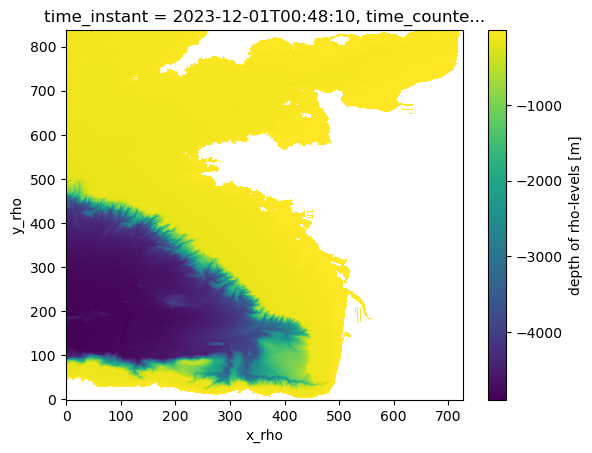

In [89]:
zz.plot()